# Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

## Problem Statement:
Suppose you are the CEO of a restaurant franchise and are considering new cities for opening a new outlet.
- You would like to expand your business to cities that may give your restaurant higher profits.
- The chain already had certain restaurants in various cities and you have data for profits and population from the cities.
- You also have data on cities that are candidates for a new restaurant.
- For these cities, you have the city population.

Use the data to help you identify which cities may potentially give you business higher profit?

## Dataset

In [2]:
def load_data(path):
    data = np.loadtxt(path,delimiter=',')
    X = data[:,0]
    y = data[:,1]

    return X,y

- x_train is population of cities
- y_train is profit of a restaurant in that city.

both x_train and y_train are numpy arrays

In [3]:
path = r"C:\Machine Learning\Coursera\Supervised ML (Regression and Classification)\02_Regression_Multiple_Variable\ex1data1.txt"

x_train, y_train = load_data(path)

In [4]:
print("Type of x_train:", type(x_train))
print("First five elements of x_train:\n", x_train[:5])
# 6.1101 means 6.1101 * 10000 = 61,101 population

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train:
 [6.1101 5.5277 8.5186 7.0032 5.8598]


In [5]:
print("Type of y_train:", type(y_train))
print("First five elements of y_train:\n", y_train[:5])
# 17.592 means 17.592 * $10,000 = $175,920

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train:
 [17.592   9.1302 13.662  11.854   6.8233]


### Check the dimensions of your variables

In [6]:
print("The shape of x_train is:", x_train.shape)
print("The shape of y_train is:", y_train.shape)
print("Number of training examples(m):", len(x_train))

The shape of x_train is: (97,)
The shape of y_train is: (97,)
Number of training examples(m): 97


### Visualize Data
- it is often useful to understand the data by visualizing it.
- for this dataset, we can use a scatter plot as it has only two properties.
- when we have more than two properties, we will still use the scatter plot for each pair of properties.

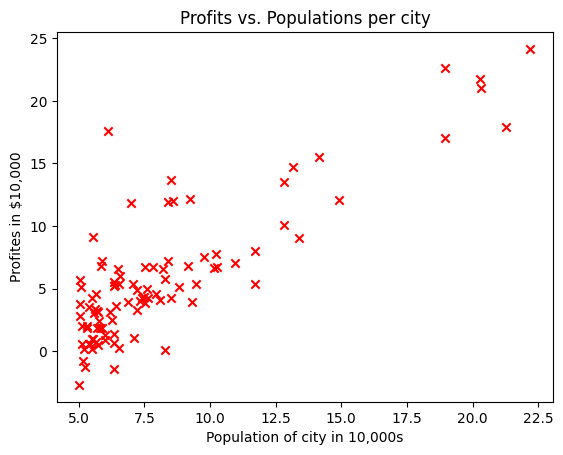

In [7]:
plt.scatter(x_train,y_train, marker='x',color='r')

plt.title("Profits vs. Populations per city")
plt.ylabel("Profites in $10,000")
plt.xlabel("Population of city in 10,000s")
plt.show()

## Compute Cost

In [8]:
def compute_cost(x,y,w,b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i])**2

    return cost/(2*m)

In [9]:
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}')

<class 'numpy.float64'>
Cost at initial w: 75.203


## Compute Gradient

In [10]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * (x[i])
        dj_db += (f_wb - y[i])

    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

In [12]:
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639
